In [222]:
%pip install matplotlib numpy scikit-learn pandas --quiet

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.1.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [717]:
# Package imports
import matplotlib
import matplotlib.pyplot as plt
import sklearn
import pandas as pd
import numpy as np

# Task 1 Implement Logistic Regression

In [718]:
# Prediction function
def predict(Xi, W, b):
    z = np.dot(Xi, W) + b
    y_hat = 1 / (1 + np.exp(-z))
    return y_hat

In [723]:
# Stochastic Gradient Descent function
def stochastic_gradient_descent(X, y, W, b, alpha=0.01, max_iters=1000, threshold=1e-4):
    # TODO: Stop with the average cost function change less than threshold
    # TODO: This version does not have loops on backpropagation because it is for just one neuron
    N = X.shape[0]
    stopping = False
    J_running = 0
    J_running_prev = 0
    iteration = 0

    while not stopping:
        # Randomly select one data point #Sample size = 1        
        i_random = np.random.randint(0, high=N)
        y_hat = predict(X[i_random], W, b)
        J_current = - (y[i_random] * np.log(y_hat) + (1 - y[i_random]) * np.log(1 - y_hat))
        error = y_hat - y[i_random]
        
        delta_W = error * X[i_random]
        delta_b = error
        
        W -= alpha * delta_W
        b -= alpha * delta_b

        # Check stopping criteria
        iteration += 1
        J_running += J_current
        if iteration >= max_iters:
            stopping = True
        if iteration % N == 0:
            if iteration % (5*N) == 0:
                # print("Average cost function over epoch:", J_running / N)
                print("Epoch:", iteration // N, " Cost:", J_running, " Previous Cost:", J_running_prev)
                print("Difference in cost function:", abs(J_running - J_running_prev))
            if abs(J_running - J_running_prev) < threshold:
                stopping = True
            J_running_prev = J_running
            J_running = 0
        
    return W, b

# Task 2 Implement Logistic Regression

- Read both files
- Split train(70), test(15), validation(15)
- Train logistic regressor and check performance
- Scatter plot of results

In [720]:
# Reading data function
def read_data(file_path):
    df = pd.read_csv(file_path)
    y = df['Class'].values   # Labels
    X = df.drop('Class', axis=1).values  # Features
    return X, y

In [721]:
def split_data(X, y, train_ratio=0.7, test_ratio=0.15, validation_ratio=0.15, random_state=1):
    # https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.train_test_split.html
    X_train, X_test_pre, y_train, y_test_pre = sklearn.model_selection.train_test_split(
    X, y, train_size=train_ratio, random_state=random_state)
    
    X_test, X_val, y_test, y_val = sklearn.model_selection.train_test_split(
    X_test_pre, y_test_pre, train_size=test_ratio/(test_ratio + validation_ratio), random_state=random_state)
    
    return X_train, y_train, X_test, y_test, X_val, y_val

## Blobs 600 dataset

In [725]:
file_path = 'Datasets/blobs600.csv'
# file_path = 'Datasets/circles500.csv'
X, y = read_data(file_path)
# Split data into training, testing, and validation sets
X_train, y_train, X_test, y_test, X_val, y_val = split_data(X, y)
# Initialize weights and bias
np.random.seed(3301)
W = np.random.normal(0,0.01,X.shape[1])
b = np.random.normal(0,0.01,1)

# Training the model using Stochastic Gradient Descent
W_trained, b_trained = stochastic_gradient_descent(X_train, y_train, W, b, alpha=0.01, max_iters=10000, threshold=1e-4)
# print("Trained Weights:", W_trained)
# print("Trained Bias:", b_trained)

Epoch: 5  Cost: [14.49132644]  Previous Cost: [18.7976724]
Difference in cost function: [4.30634596]
Epoch: 10  Cost: [13.19302473]  Previous Cost: [11.00449937]
Difference in cost function: [2.18852537]
Epoch: 15  Cost: [8.43640352]  Previous Cost: [6.72937081]
Difference in cost function: [1.7070327]
Epoch: 20  Cost: [4.74670646]  Previous Cost: [5.87995414]
Difference in cost function: [1.13324767]


In [726]:
treshold = 0.5

y_hat_train = predict(X_train, W_trained, b_trained)
y_pred_train = (y_hat_train >= treshold).astype(int)

y_hat_test = predict(X_test, W_trained, b_trained)
y_pred_test = (y_hat_test >= treshold).astype(int)

y_hat_val = predict(X_val, W_trained, b_trained)
y_pred_val = (y_hat_val >= treshold).astype(int)

accuracy_train = np.mean(y_pred_train == y_train)
accuracy_test = np.mean(y_pred_test == y_test)
accuracy_val = np.mean(y_pred_val == y_val)
print("Train Accuracy:", accuracy_train)
print("Test Accuracy:", accuracy_test)
print("Validation Accuracy:", accuracy_val)

Train Accuracy: 0.9976190476190476
Test Accuracy: 0.9888888888888889
Validation Accuracy: 0.9888888888888889


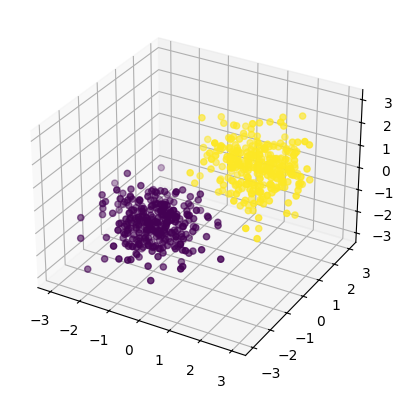

In [727]:
# Scatter plot of test results
# https://stackoverflow.com/questions/12414619/creating-a-3d-plot-from-a-3d-numpy-array
X_all = np.vstack((X_train, X_test, X_val))
y_pred_all = np.hstack((y_pred_train, y_pred_test, y_pred_val))

fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
ax.scatter(X_all[:, 0], X_all[:, 1], X_all[:, 2], c=y_pred_all)

## Circles 500 dataset

In [752]:
# file_path = 'Datasets/blobs600.csv'
file_path = 'Datasets/circles500.csv'
X, y = read_data(file_path)
# Split data into training, testing, and validation sets
X_train, y_train, X_test, y_test, X_val, y_val = split_data(X, y)
# Initialize weights and bias
np.random.seed(3301)
W = np.random.normal(0,0.01,X.shape[1])
b = np.random.normal(0,0.01,1)

# Training the model using Stochastic Gradient Descent
W_trained, b_trained = stochastic_gradient_descent(X_train, y, W, b, alpha=1e-4, max_iters=10000, threshold=1e-6)
print("Trained Weights:", W_trained)
print("Trained Bias:", b_trained)

Epoch: 5  Cost: [242.76672586]  Previous Cost: [242.75791476]
Difference in cost function: [0.0088111]
Epoch: 10  Cost: [242.73321486]  Previous Cost: [242.72339249]
Difference in cost function: [0.00982237]
Epoch: 15  Cost: [242.66679956]  Previous Cost: [242.74261753]
Difference in cost function: [0.07581797]
Epoch: 20  Cost: [242.59438376]  Previous Cost: [242.57949554]
Difference in cost function: [0.01488822]
Epoch: 25  Cost: [242.53320083]  Previous Cost: [242.56578993]
Difference in cost function: [0.0325891]
Trained Weights: [0.01119526 0.00745474]
Trained Bias: [0.00265608]


In [753]:
treshold = 0.5

y_hat_train = predict(X_train, W_trained, b_trained)
y_pred_train = (y_hat_train >= treshold).astype(int)

y_hat_test = predict(X_test, W_trained, b_trained)
y_pred_test = (y_hat_test >= treshold).astype(int)

y_hat_val = predict(X_val, W_trained, b_trained)
y_pred_val = (y_hat_val >= treshold).astype(int)

accuracy_train = np.mean(y_pred_train == y_train)
accuracy_test = np.mean(y_pred_test == y_test)
accuracy_val = np.mean(y_pred_val == y_val)
print("Train Accuracy:", accuracy_train)
print("Test Accuracy:", accuracy_test)
print("Validation Accuracy:", accuracy_val)

Train Accuracy: 0.5257142857142857
Test Accuracy: 0.64
Validation Accuracy: 0.5066666666666667


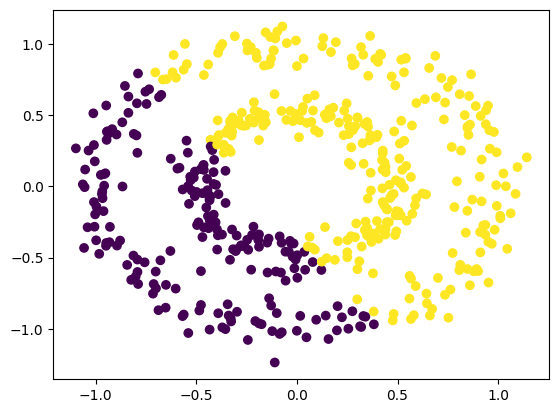

In [754]:
# Scatter plot of test results
# https://stackoverflow.com/questions/12414619/creating-a-3d-plot-from-a-3d-numpy-array
X_all = np.vstack((X_train, X_test, X_val))
y_pred_all = np.hstack((y_pred_train, y_pred_test, y_pred_val))

fig = plt.figure()
ax = fig.add_subplot()
ax.scatter(X_all[:, 0], X_all[:, 1], c=y_pred_all)

# Task 3: Implement and Test a Shallow Neural Network

- 1 hidden layer
- 1 output node
- Support different number of inputs and different number of nodes in the hidden layer

- Test previous datasets with different number of nodes in the hidden layer
- Measure performance

In [755]:
def parameter_initialization(X, neurons_hidden_layer):
    np.random.seed(3301)
    W1 = np.random.normal(0,0.01,size=(neurons_hidden_layer,X.shape[1]))
    W2 = np.random.normal(0,0.01,size=(1,neurons_hidden_layer))
    W = [W1, W2]

    b1 = np.random.normal(0,0.01,size=(neurons_hidden_layer))
    b2 = np.random.normal(0,0.01,size=(1))
    b = [b1, b2]
    
    # https://numpy.org/devdocs/reference/generated/numpy.zeros.html
    z1 = np.zeros(shape=(neurons_hidden_layer))
    z2 = np.zeros(shape=(1))
    z = [z1, z2]
    a0 = np.zeros(shape=(X.shape[1]))
    a1 = np.zeros(shape=(neurons_hidden_layer))
    a2 = np.zeros(shape=(1))
    a = [a0, a1, a2]

    return W, b, z, a

In [756]:
# Forward propagation function
def forward_propagation(Xi, W, b, z, a):
   # X[observation][feature] 
   # W[layer][destination_node][source_node]
   # b[layer][destination_node]
   # z[layer][destination_node]
   # a[layer][destination_node]
   a[0] = Xi # Inputs are activations of layer 0
   for layer in range(1, 3):
      for destination_node in range(1, len(z[layer-1])+1):
         # Linear transformation 
         z[layer-1][destination_node-1] = np.dot(a[layer-1], W[layer-1][destination_node-1]) + b[layer-1][destination_node-1]
         # Activation function (Using logistic function)
         a[layer][destination_node-1] = 1 / (1 + np.exp(-z[layer-1][destination_node-1]))

   y_hat = a[layer][destination_node-1] # Output of the last layer is the prediction
   return y_hat, a, z

In [757]:
# Return only the prediction
def predict(X, W, b, z, a):
    y_hats = np.zeros(shape=(X.shape[0]))
    for i, Xi in enumerate(X):
        y_hat, a, z = forward_propagation(Xi, W, b, z, a)
        y_hats[i] = y_hat
    return y_hats

In [800]:
# Backpropagation and gradient descent function
def gradient_descent_t3(X, y, W, b, a, z, alpha=0.01, max_iters=1000, threshold=1e-4, neurons_hidden_layer=5):
    N = X.shape[0]
    stopping = False
    J_running = 0
    J_running_prev = 0
    iteration = 0
    # Initialize delta parameters for gradient descent
    delta_W1 = np.zeros(shape=(neurons_hidden_layer,X.shape[1]))
    delta_W2 = np.zeros(shape=(1,neurons_hidden_layer))
    delta_W = [delta_W1, delta_W2]

    delta_b1 = np.zeros(shape=(neurons_hidden_layer))
    delta_b2 = np.zeros(shape=(1))
    delta_b = [delta_b1, delta_b2]

    delta_z1 = np.zeros(shape=(neurons_hidden_layer))
    delta_z2 = np.zeros(shape=(1))
    delta_z = [delta_z1, delta_z2]
    
    while not stopping:
        # Randomly select one data point #Sample size = 1       
        i_random = np.random.randint(0, high=N)
        y_hat, a, z = forward_propagation(X[i_random], W, b, z, a)
        J_current = - (y[i_random] * np.log(y_hat) + (1 - y[i_random]) * np.log(1 - y_hat))
        
        # Backpropagation step
        error = y_hat - y[i_random] 
        for layer in range(len(W), 0, -1):
            # Output layer gradients
            if layer == len(W):
                delta_z[layer-1] = error
                # https://numpy.org/doc/2.3/reference/generated/numpy.reshape.html
                delta_W[layer-1] = error * a[layer-1].reshape(1, -1)
                delta_b[layer-1] = error
            # Hidden layer gradients
            else:
                # Derivative of logistic is f(z) * (1 - f(z)). Therefore, we can use the activation layer instead of calculating the logistic function again
                delta_z[layer-1] = (a[layer] * (1 - a[layer]))         *       delta_z[layer] * W[layer].reshape(-1)
                # https://numpy.org/doc/stable/reference/generated/numpy.outer.html
                delta_W[layer-1] = np.outer(delta_z[layer-1], a[layer-1])
                delta_b[layer-1] = delta_z[layer-1]

        # Update parameters step
        for layer in range(1, len(W)+1):
            W[layer-1] -= alpha * delta_W[layer-1]
            b[layer-1] -= alpha * delta_b[layer-1]
        
        # Check stopping criteria
        iteration += 1
        J_running += J_current
        if iteration >= max_iters:
            stopping = True
        if iteration % N == 0: # 1 Epoch finished
            if iteration % (100*N) == 0:
                # print("Average cost function over epoch:", J_running / N)
                print("Epoch:", iteration // N, " Cost:", J_running, " Previous Cost:", J_running_prev)
                print("Difference in cost function:", abs(J_running - J_running_prev))
            if abs(J_running - J_running_prev) < threshold:
                stopping = True
            J_running_prev = J_running
            J_running = 0
        
    return W, b, a, z  

## Circles 500 dataset

In [832]:
# file_path = 'Datasets/blobs600.csv'
file_path = 'Datasets/circles500.csv'
X, y = read_data(file_path)
# Split data into training, testing, and validation sets
X_train, y_train, X_test, y_test, X_val, y_val = split_data(X, y)
# Initialize weights and bias
np.random.seed(3301)
neurons_hidden_layer = 4
W, b, z, a = parameter_initialization(X, neurons_hidden_layer=neurons_hidden_layer)

# Training the model using Stochastic Gradient Descent
W_trained, b_trained, a_trained, z_trained = gradient_descent_t3(X_train, y_train, W, b, a, z, alpha=1e-1, max_iters=100000, threshold=1e-4, neurons_hidden_layer=neurons_hidden_layer)
# print("Trained Weights:", W_trained)
# print("Trained Bias:", b_trained)

Epoch: 100  Cost: 246.45004222095002  Previous Cost: 245.23161103834417
Difference in cost function: 1.2184311826058547
Epoch: 200  Cost: 45.62062236715323  Previous Cost: 44.33494996360777
Difference in cost function: 1.2856724035454619


In [833]:
treshold = 0.5
y_hat_train= predict(X_train, W_trained, b_trained, z_trained, a_trained) 
y_pred_train = (y_hat_train >= treshold).astype(int)

y_hat_test= predict(X_test, W_trained, b_trained, z_trained, a_trained) 
y_pred_test = (y_hat_test >= treshold).astype(int)

y_hat_val= predict(X_val, W_trained, b_trained, z_trained, a_trained) 
y_pred_val = (y_hat_val >= treshold).astype(int)

In [834]:
accuracy_train = np.mean(y_pred_train == y_train)
accuracy_test = np.mean(y_pred_test == y_test)
accuracy_val = np.mean(y_pred_val == y_val)
print("Train Accuracy:", accuracy_train)
print("Test Accuracy:", accuracy_test)
print("Validation Accuracy:", accuracy_val)
# Scatter plot of test results
# https://stackoverflow.com/questions/12414619/creating-a-3d-plot-from-a-3d-numpy-array
X_all = np.vstack((X_train, X_test, X_val))
y_pred_all = np.hstack((y_pred_train, y_pred_test, y_pred_val))

Train Accuracy: 0.9885714285714285
Test Accuracy: 0.9866666666666667
Validation Accuracy: 0.9733333333333334


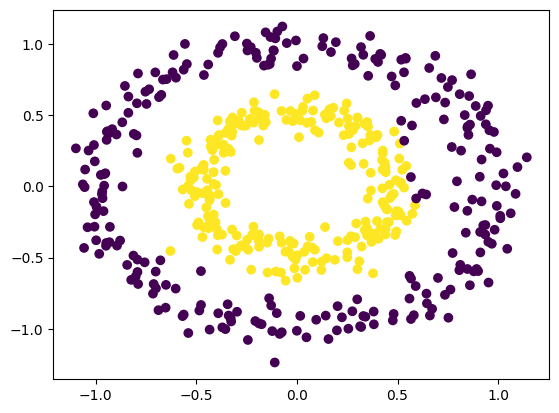

In [835]:
fig = plt.figure()
ax = fig.add_subplot()
ax.scatter(X_all[:, 0], X_all[:, 1], c=y_pred_all)

In [ ]:
# neurons_hidden_layer = 5
# alpha = 0.01


# N = X.shape[0]
# stopping = False
# J_running = 0
# J_running_prev = 0
# iteration = 0
# # Initialize delta parameters for gradient descent
# delta_W1 = np.zeros(shape=(neurons_hidden_layer,X.shape[1]))
# delta_W2 = np.zeros(shape=(1,neurons_hidden_layer))
# delta_W = [delta_W1, delta_W2]

# delta_b1 = np.zeros(shape=(neurons_hidden_layer))
# delta_b2 = np.zeros(shape=(1))
# delta_b = [delta_b1, delta_b2]

# delta_z1 = np.zeros(shape=(neurons_hidden_layer))
# delta_z2 = np.zeros(shape=(1))
# delta_z = [delta_z1, delta_z2]


# # while not stopping:

# # Randomly select one data point #Sample size = 1       
# i_random = np.random.randint(0, high=N)
# y_hat, a, z = forward_propagation(X[i_random], W, b, z, a)
# J_current = - (y[i_random] * np.log(y_hat) + (1 - y[i_random]) * np.log(1 - y_hat))

# # Backpropagation step
# error = y_hat - y[i_random] 
# for layer in range(len(W), 0, -1):
#     print("Layer:", layer)
#     # Output layer gradients
#     if layer == len(W):
#         delta_z[layer-1] = error
#         delta_W[layer-1] = error * a[layer-1]
#         delta_b[layer-1] = error
#     # Hidden layer gradients
#     else:
#         # Derivative of logistic is f(z) * (1 - f(z)). Therefore, we can use the activation layer instead of calculating the logistic function again
#         delta_z[layer-1] = (a[layer] * (1 - a[layer]))         *       delta_z[layer] * delta_W[layer]
#         # https://numpy.org/doc/stable/reference/generated/numpy.outer.html
#         delta_W[layer-1] = np.outer(delta_z[layer-1], a[layer-1])
#         delta_b[layer-1] = delta_z[layer-1]

# # Update parameters step
# for layer in range(1, len(W)+1):
#     print("Layer:", layer)
#     W[layer-1] -= alpha * delta_W[layer-1]
#     b[layer-1] -= alpha * delta_b[layer-1]